<a href="https://colab.research.google.com/github/jaiswalakanksha22-glitch/Python-AI/blob/main/Project2_Jaiswal_Akanksha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving PRSA_Data_Aotizhongxin_20130301-20170228.csv to PRSA_Data_Aotizhongxin_20130301-20170228.csv
Saving PRSA_Data_Changping_20130301-20170228.csv to PRSA_Data_Changping_20130301-20170228.csv
Saving PRSA_Data_Dingling_20130301-20170228.csv to PRSA_Data_Dingling_20130301-20170228.csv
Saving PRSA_Data_Dongsi_20130301-20170228.csv to PRSA_Data_Dongsi_20130301-20170228.csv
Saving PRSA_Data_Guanyuan_20130301-20170228.csv to PRSA_Data_Guanyuan_20130301-20170228.csv
Saving PRSA_Data_Gucheng_20130301-20170228.csv to PRSA_Data_Gucheng_20130301-20170228.csv
Saving PRSA_Data_Huairou_20130301-20170228.csv to PRSA_Data_Huairou_20130301-20170228.csv
Saving PRSA_Data_Nongzhanguan_20130301-20170228.csv to PRSA_Data_Nongzhanguan_20130301-20170228.csv
Saving PRSA_Data_Shunyi_20130301-20170228.csv to PRSA_Data_Shunyi_20130301-20170228.csv
Saving PRSA_Data_Tiantan_20130301-20170228.csv to PRSA_Data_Tiantan_20130301-20170228.csv
Saving PRSA_Data_Wanliu_20130301-20170228.csv to PRSA_Data_Wanliu_20130301-2

1. Load the dataset, PRSA_Data.csv, into memory.

In [16]:

import pandas as pd
import glob

files = glob.glob('/content/PRSA_Data_*.csv')
print(files)

df_list = [pd.read_csv(file) for file in files]
df = pd.concat(df_list, ignore_index=True)

df.head()

['/content/PRSA_Data_Gucheng_20130301-20170228.csv', '/content/PRSA_Data_Huairou_20130301-20170228.csv', '/content/PRSA_Data_Wanshouxigong_20130301-20170228.csv', '/content/PRSA_Data_Shunyi_20130301-20170228.csv', '/content/PRSA_Data_Changping_20130301-20170228.csv', '/content/PRSA_Data_Tiantan_20130301-20170228.csv', '/content/PRSA_Data_Wanliu_20130301-20170228.csv', '/content/PRSA_Data_Dongsi_20130301-20170228.csv', '/content/PRSA_Data_Guanyuan_20130301-20170228.csv', '/content/PRSA_Data_Nongzhanguan_20130301-20170228.csv', '/content/PRSA_Data_Dingling_20130301-20170228.csv', '/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


In [17]:
print(df.shape)
print(df.columns)

(420768, 18)
Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')


2. Clean the data and check missing values for this dataset.

In [18]:

df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


In [19]:
df.isnull().sum(axis=0)

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [20]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 74027


In [21]:
# clean missing values
df = df.drop(columns=['No'])

df = df.fillna(df.median(numeric_only=True))
df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

3. Convert all categorical variables to numerical values.

In [22]:
catFeatures = ['wd', 'station']

factors = pd.get_dummies(df[catFeatures], drop_first=True)
factors.head()


,wd_ENE,wd_ESE,wd_N,wd_NE,wd_NNE,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,...,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong
0,False,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [23]:
df = df.drop(catFeatures, axis=1)
df = pd.concat([df, factors], axis=1)
df.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,...,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong
0,2013,3,1,0,6.0,18.0,5.0,43.0,800.0,88.0,...,False,False,False,True,False,False,False,False,False,False
1,2013,3,1,1,6.0,15.0,5.0,43.0,800.0,88.0,...,False,False,False,True,False,False,False,False,False,False
2,2013,3,1,2,5.0,18.0,7.0,43.0,700.0,52.0,...,False,False,False,True,False,False,False,False,False,False
3,2013,3,1,3,6.0,20.0,6.0,43.0,900.0,45.0,...,False,False,False,True,False,False,False,False,False,False
4,2013,3,1,4,5.0,17.0,5.0,43.0,600.0,73.0,...,False,False,False,True,False,False,False,False,False,False


4. Split the data into 80% of training and 20% of the test dataset.

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop('PM2.5', axis=1)
y = df['PM2.5']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(336614, 40)
(84154, 40)
(336614,)
(84154,)


5. Preprocess the data using the normalization method to convert all features into the range of [0,1]

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

6. Build a neuron network with two hidden layers of 20 and 10 neurons to forecast PM2.5 using all other features and TensorFlow. Does it overfit or underfit the data? Please justify your answer.

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# build model
model = Sequential([
    Dense(20, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(10, activation='relu'),
    Dense(1)   # output layer for PM2.5 prediction
])

# compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# train model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 1792.8428 - mae: 26.2269 - val_loss: 938.0369 - val_mae: 19.3426
Epoch 2/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 912.4681 - mae: 19.1452 - val_loss: 904.1258 - val_mae: 19.0853
Epoch 3/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 880.5135 - mae: 18.8033 - val_loss: 870.4141 - val_mae: 18.7167
Epoch 4/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 855.0914 - mae: 18.5120 - val_loss: 845.4138 - val_mae: 18.3398
Epoch 5/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 822.6691 - mae: 18.1129 - val_loss: 807.9143 - val_mae: 17.8791
Epoch 6/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 781.5258 - mae: 17.6010 - val_loss: 763.3896 - val_mae: 17.4029
Epoch 7/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 743.9809 - mae: 17.2277 - val_loss: 728.4998 - val_mae: 17.1087
Epoch 8/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 718.6204 - mae: 17.0028 - val_loss: 708.6240 - 

In [29]:
train_loss, train_mae = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print("Training Loss (MSE):", train_loss)
print("Training MAE:", train_mae)
print("Testing Loss (MSE):", test_loss)
print("Testing MAE:", test_mae)

Training Loss (MSE): 549.37451171875
Training MAE: 14.666187286376953
Testing Loss (MSE): 558.157958984375
Testing MAE: 14.78774356842041


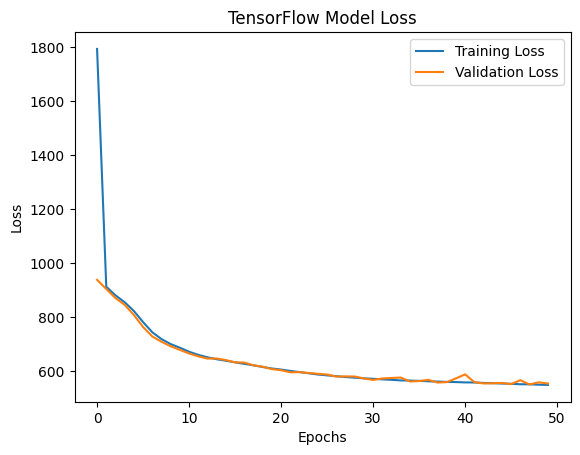

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('TensorFlow Model Loss')
plt.legend()
plt.show()

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

2630/2630 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Test RMSE: 23.625351896112466
Test MAE: 14.787743819251183
Test R2: 0.913317712809022


**The TensorFlow model does not appear to overfit or underfit. The training and testing losses are very similar (549.37 vs 558.16), and the training and testing MAE values are also close (14.67 vs 14.79). This indicates that the model generalizes well to unseen data. The R² score of 0.9133 further shows that the model performs well in predicting PM2.5.**

7. Tune the model using the following hyperparameters using keras-tuner:
First hidden layer with units between 20 and 50 with a step size of 5
Second hidden layer with units between 5 and 10 with a step size of 1
The dropout rate for both hidden layer is between 0.2 and 0.8 with a step size of 0.1
Please recommend the optimal model and specify the hyperparameters.

In [36]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.7 MB/s eta 0:00:00


In [37]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [55]:
#Define the model-building function
def build_model(hp):
    model = Sequential()

    # first hidden layer
    units1 = hp.Int('units1', min_value=20, max_value=50, step=5)
    drop1 = hp.Float('dropout1', min_value=0.2, max_value=0.8, step=0.1)

    model.add(Dense(units=units1, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(drop1))

    # second hidden layer
    units2 = hp.Int('units2', min_value=5, max_value=10, step=1)
    drop2 = hp.Float('dropout2', min_value=0.2, max_value=0.8, step=0.1)

    model.add(Dense(units=units2, activation='relu'))
    model.add(Dropout(drop2))

    # output layer
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [56]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='pm25_tuning'
)

Reloading Tuner from keras_tuner_dir/pm25_tuning/tuner0.json


In [57]:
import IPython
#Clear all the training outputs
class ClearTrainingOutput(tf.keras.callbacks.Callback):
  def on_train_end(*args, **kwargs):
    IPython.display.clear_output(wait = True)

In [58]:
tuner.search(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Trial 59 Complete [00h 13m 01s]
val_loss: 2177.52734375

Best val_loss So Far: 880.6905517578125
Total elapsed time: 01h 03m 48s


In [59]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best first hidden layer units:", best_hp.get('units1'))
print("Best second hidden layer units:", best_hp.get('units2'))
print("Best first dropout rate:", best_hp.get('dropout1'))
print("Best second dropout rate:", best_hp.get('dropout2'))

Best first hidden layer units: 40
Best second hidden layer units: 7
Best first dropout rate: 0.2
Best second dropout rate: 0.2


In [61]:
best_model = tuner.hypermodel.build(best_hp)

history_best = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 2518.7522 - mae: 31.2459 - val_loss: 948.9958 - val_mae: 19.2284
Epoch 2/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 1611.1990 - mae: 24.3782 - val_loss: 878.7365 - val_mae: 18.4043
Epoch 3/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 1523.1720 - mae: 23.6600 - val_loss: 854.1181 - val_mae: 18.1920
Epoch 4/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 1445.7152 - mae: 22.9877 - val_loss: 799.1347 - val_mae: 17.5650
Epoch 5/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 1347.4965 - mae: 22.2906 - val_loss: 773.4645 - val_mae: 17.3357
Epoch 6/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 1318.2499 - mae: 21.9114 - val_loss: 745.3181 - val_mae: 17.1412
Epoch 7/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 1263.6422 - mae: 21.5332 - val_loss: 697.8113 - val_mae: 16.7456
Epoch 8/50
8416/8416 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 1227.5298 - mae: 21.2600 - val_loss: 678.

In [62]:
train_loss, train_mae = best_model.evaluate(X_train, y_train, verbose=0)
test_loss, test_mae = best_model.evaluate(X_test, y_test, verbose=0)

print("Best Model Training Loss (MSE):", train_loss)
print("Best Model Training MAE:", train_mae)
print("Best Model Testing Loss (MSE):", test_loss)
print("Best Model Testing MAE:", test_mae)

Best Model Training Loss (MSE): 590.045166015625
Best Model Training MAE: 16.018054962158203
Best Model Testing Loss (MSE): 599.6124877929688
Best Model Testing MAE: 16.120332717895508


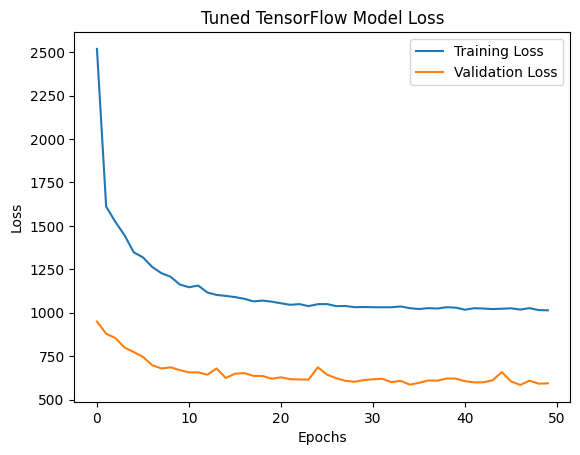

In [63]:
import matplotlib.pyplot as plt

plt.plot(history_best.history['loss'], label='Training Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Tuned TensorFlow Model Loss')
plt.legend()
plt.show()

In [64]:
print(f"""
Recommended optimal model:
- First hidden layer units: {best_hp.get('units1')}
- Second hidden layer units: {best_hp.get('units2')}
- First dropout rate: {best_hp.get('dropout1')}
- Second dropout rate: {best_hp.get('dropout2')}
""")


Recommended optimal model:
- First hidden layer units: 40
- Second hidden layer units: 7
- First dropout rate: 0.2
- Second dropout rate: 0.2



**The optimal TensorFlow model recommended by Keras Tuner uses 40 neurons in the first hidden layer and 7 neurons in the second hidden layer. The optimal dropout rate for both hidden layers is 0.2. This model is recommended because it achieved the lowest validation loss among the tested hyperparameter combinations.**

8. Build a neuron network with two hidden layers of 20 and 10 neurons to forecast PM2.5 using all other features and PyTorch. Does it overfit or underfit the data? Please justify your answer.

In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [66]:
# Convert data to PyTorch tensors
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_torch = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [67]:
# Create DataLoader
train_dataset = TensorDataset(X_train_torch, y_train_torch)
test_dataset = TensorDataset(X_test_torch, y_test_torch)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [68]:
# Define PyTorch neural network
class PM25Model(nn.Module):
    def __init__(self, input_size):
        super(PM25Model, self).__init__()
        self.fc1 = nn.Linear(input_size, 20)
        self.fc2 = nn.Linear(20, 10)
        self.fc3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [69]:
# Initialize model
input_size = X_train.shape[1]
model_torch = PM25Model(input_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_torch.parameters(), lr=0.001)

In [70]:
# Train the model
num_epochs = 50
train_losses = []

for epoch in range(num_epochs):
    model_torch.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_torch(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}")

Epoch [1/50], Loss: 1837.8762
Epoch [2/50], Loss: 1006.8498
Epoch [3/50], Loss: 1004.5716
Epoch [4/50], Loss: 1002.4940
Epoch [5/50], Loss: 999.3749
Epoch [6/50], Loss: 984.6367
Epoch [7/50], Loss: 916.0297
Epoch [8/50], Loss: 833.5705
Epoch [9/50], Loss: 792.8540
Epoch [10/50], Loss: 767.8366
Epoch [11/50], Loss: 749.9071
Epoch [12/50], Loss: 734.5969
Epoch [13/50], Loss: 719.9794
Epoch [14/50], Loss: 706.6533
Epoch [15/50], Loss: 695.4810
Epoch [16/50], Loss: 686.6335
Epoch [17/50], Loss: 677.0355
Epoch [18/50], Loss: 669.3182
Epoch [19/50], Loss: 662.2229
Epoch [20/50], Loss: 657.0774
Epoch [21/50], Loss: 652.4407
Epoch [22/50], Loss: 650.0786
Epoch [23/50], Loss: 647.4151
Epoch [24/50], Loss: 645.6360
Epoch [25/50], Loss: 643.8586
Epoch [26/50], Loss: 642.3594
Epoch [27/50], Loss: 640.9263
Epoch [28/50], Loss: 639.7291
Epoch [29/50], Loss: 637.9905
Epoch [30/50], Loss: 635.2611
Epoch [31/50], Loss: 631.3921
Epoch [32/50], Loss: 627.2719
Epoch [33/50], Loss: 623.7906
Epoch [34/50], 

In [71]:
# Evaluate on test data
model_torch.eval()
with torch.no_grad():
    y_pred_torch = model_torch(X_test_torch)
    test_loss = criterion(y_pred_torch, y_test_torch).item()

print("PyTorch Test MSE:", test_loss)

PyTorch Test MSE: 597.6887817382812


In [72]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

y_pred_np = y_pred_torch.numpy()

print("PyTorch Test RMSE:", np.sqrt(test_loss))
print("PyTorch Test MAE:", mean_absolute_error(y_test, y_pred_np))
print("PyTorch Test R2:", r2_score(y_test, y_pred_np))

PyTorch Test RMSE: 24.447674362570385
PyTorch Test MAE: 15.276023625077544
PyTorch Test R2: 0.9071784310182398


**The PyTorch neural network does not show strong signs of overfitting or underfitting. The model achieved a test MSE of 597.69, RMSE of 24.45, MAE of 15.28, and R² of 0.9072. The R² value shows that the model explains about 90.72% of the variance in PM2.5, which indicates strong predictive performance. Since the error values are reasonably low and the overall predictive accuracy is high, the model appears to generalize well to unseen data.**